In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("/Users/zehongyang/PycharmProjects/PythonProject/.ipynb_checkpoints/realtor.csv")

In [3]:
print(df.head())
print(df.shape)
df.info()
print(df.isnull().sum())
print(df.describe())


   brokered_by    status     price  bed  bath  acre_lot     street  \
0     103378.0  for_sale  105000.0  3.0   2.0      0.12  1962661.0   
1      52707.0  for_sale   80000.0  4.0   2.0      0.08  1902874.0   
2     103379.0  for_sale   67000.0  2.0   1.0      0.15  1404990.0   
3      31239.0  for_sale  145000.0  4.0   2.0      0.10  1947675.0   
4      34632.0  for_sale   65000.0  6.0   2.0      0.05   331151.0   

         city        state  zip_code  house_size prev_sold_date  
0    Adjuntas  Puerto Rico     601.0       920.0            NaN  
1    Adjuntas  Puerto Rico     601.0      1527.0            NaN  
2  Juana Diaz  Puerto Rico     795.0       748.0            NaN  
3       Ponce  Puerto Rico     731.0      1800.0            NaN  
4    Mayaguez  Puerto Rico     680.0         NaN            NaN  
(2226382, 12)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2226382 entries, 0 to 2226381
Data columns (total 12 columns):
 #   Column          Dtype  
---  ------          ----- 

In [4]:
df["brokered_by"]= df["brokered_by"].astype("category")
df["state"] = df["state"].astype("category")
df["street"] = df["street"].astype("category")
df["city"] = df["city"].astype("category")
df["state"]= df["state"].astype("category")

In [5]:
df["bed"] = df["bed"].astype("Int64")
df["bath"] = df["bath"].astype("Int64")
df["house_size"] = df["house_size"].astype("Int64")
df["zip_code"] = df["zip_code"].astype("Int64").astype("str")
df["prev_sold_date"] = pd.to_datetime(df["prev_sold_date"], errors="coerce")


In [6]:
df.isnull().mean().sort_values(ascending=False)

prev_sold_date    0.329817
house_size        0.255340
bath              0.229867
bed               0.216188
acre_lot          0.146241
street            0.004881
brokered_by       0.002036
price             0.000692
city              0.000632
state             0.000004
status            0.000000
zip_code          0.000000
dtype: float64

In [7]:
df = df.dropna(subset=["price"])

In [8]:
num_cols = ["bed","bath","acre_lot","house_size"]

for col in num_cols:
    df[col] = df[col].fillna(df[col].median())


In [9]:
import seaborn as sns
import matplotlib.pyplot as plt

In [10]:
df["price"].describe(percentiles=[0.5,0.9,0.95,0.99])


count    2.224841e+06
mean     5.241955e+05
std      2.138893e+06
min      0.000000e+00
50%      3.250000e+05
90%      9.490000e+05
95%      1.495000e+06
99%      3.899000e+06
max      2.147484e+09
Name: price, dtype: float64

In [11]:
df[df["price"] > 1e8][["price","state","house_size"]].head(20)

,price,state,house_size
70245,1.200000e+08,New York,1760
72903,8.750000e+08,New York,2440
105334,1.690000e+08,New York,8255
105368,1.350000e+08,New York,8055
221994,2.147484e+09,California,885
271047,1.100000e+08,West Virginia,1760
375790,2.815000e+08,Georgia,1760
388357,1.626270e+08,Georgia,1760
490791,1.500000e+08,Florida,19919
509852,1.060000e+08,Florida,23188


In [12]:
df[df["price"] == 0]

,brokered_by,status,price,bed,bath,acre_lot,street,city,state,zip_code,house_size,prev_sold_date
46207,67948.0,for_sale,0.0,3,2,0.17,1378257.0,Paterson,New Jersey,7504,4500,NaT
46208,67948.0,for_sale,0.0,3,2,0.22,1385903.0,Paterson,New Jersey,7504,5000,NaT
49607,92894.0,for_sale,0.0,4,4,0.26,1012209.0,New York,New York,10016,1760,NaT
57803,67929.0,for_sale,0.0,3,2,0.26,360537.0,Jersey City,New Jersey,7302,1760,2020-03-04
116304,67937.0,for_sale,0.0,3,1,0.26,1089831.0,Queens,New York,11101,1760,2021-08-31
...,...,...,...,...,...,...,...,...,...,...,...,...
1331173,91026.0,ready_to_build,0.0,2,2,0.26,558779.0,Brentwood,California,94513,1622,NaT
1331174,91026.0,ready_to_build,0.0,2,2,0.26,558779.0,Brentwood,California,94513,1868,NaT
1331178,91026.0,ready_to_build,0.0,2,2,0.26,485787.0,Brentwood,California,94513,1962,NaT
1331181,91026.0,ready_to_build,0.0,2,2,0.26,485787.0,Brentwood,California,94513,1841,NaT


In [13]:
df = df[df["price"] > 10000]
upper = df["price"].quantile(0.99)
df = df[df["price"] < upper]

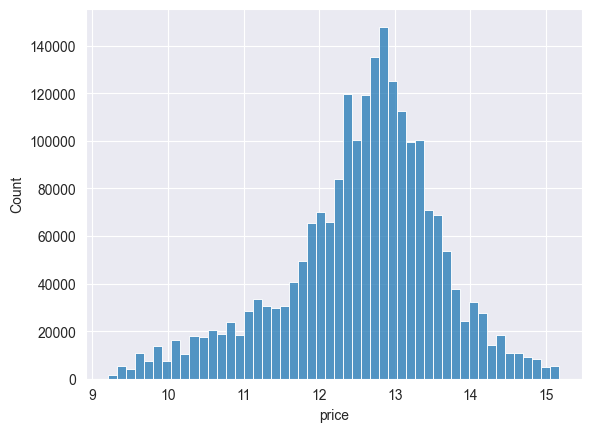

In [14]:
import numpy as np
sns.histplot(np.log1p(df["price"]), bins=50)
plt.show()

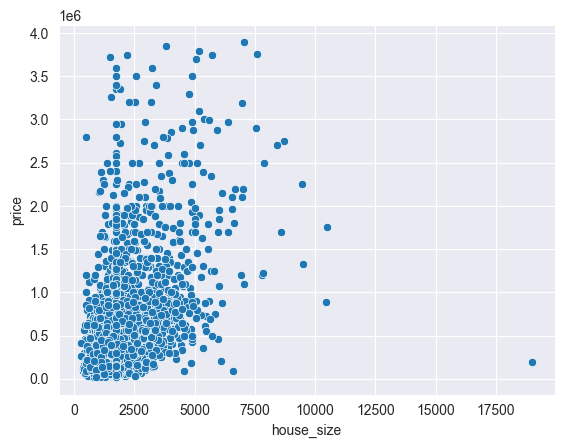

In [16]:
sns.scatterplot(x="house_size", y="price", data=df.sample(5000))
plt.show()

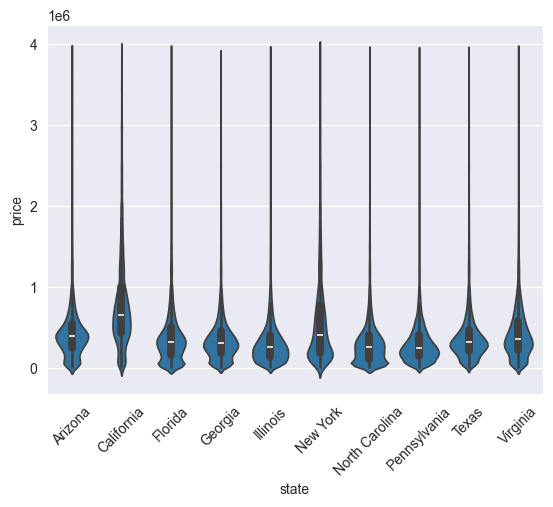

In [17]:
top_states = (
    df["state"]
    .value_counts()
    .head(10)
    .index
)

plot_df = df[df["state"].isin(top_states)].copy()

plot_df["state"] = (
    plot_df["state"]
    .cat.remove_unused_categories()
)

sns.violinplot(
    data=plot_df,
    x="state",
    y="price"
)

plt.xticks(rotation=45)
plt.show()




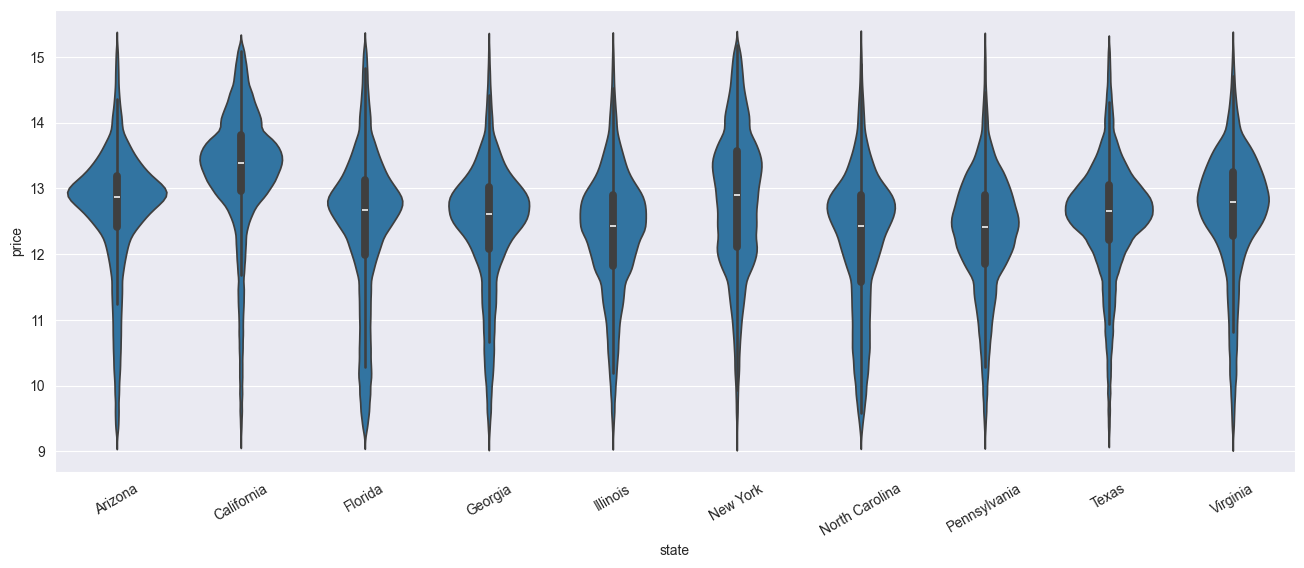

In [18]:
import numpy as np
plt.figure(figsize=(16,6))

sns.violinplot(
    data=plot_df,
    x="state",
    y=np.log1p(plot_df["price"])
)

plt.xticks(rotation=30)
plt.show()


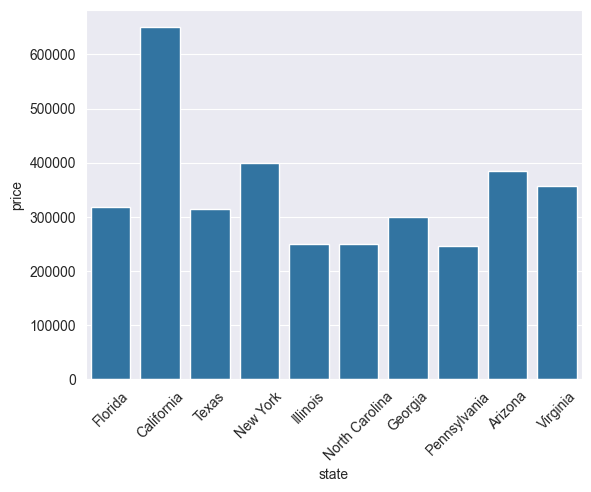

In [19]:
plot_df = df[df["state"].isin(top_states)].copy()
plot_df["state"] = plot_df["state"].astype(str)

state_price = (
    plot_df.groupby("state")["price"]
    .median()
    .reindex(top_states)
)

sns.barplot(
    data=state_price.reset_index(),
    x="state",
    y="price",
    order=top_states
)

plt.xticks(rotation=45)
plt.show()



/var/folders/_m/f269qkgj4614jnc2jd5nmf380000gn/T/ipykernel_1525/1475406303.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("state")["price"]


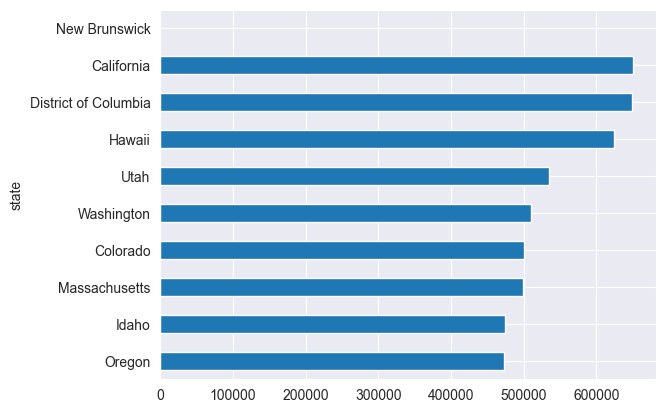

In [20]:
state_price = (
    df.groupby("state")["price"]
    .median()
    .sort_values(ascending=True)
    .tail(10)
)

state_price.plot(kind="barh")
plt.show()


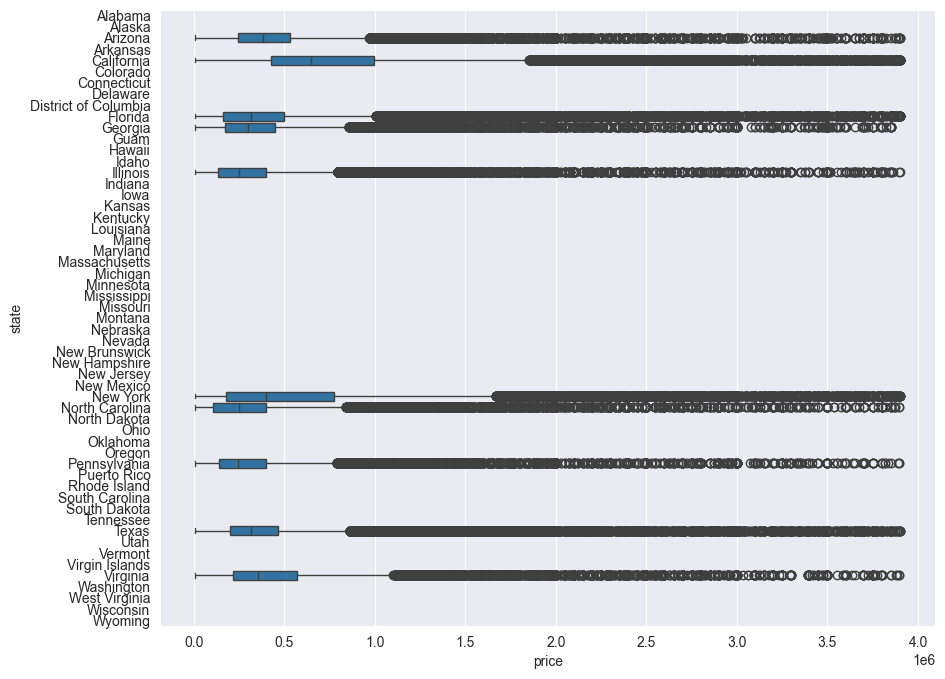

In [21]:
top_states = (
    df["state"]
    .value_counts()
    .head(10)
    .index
)

plot_df = df[df["state"].isin(top_states)]

plt.figure(figsize=(10,8))

sns.boxplot(
    data=plot_df,
    y="state",
    x="price"
)

plt.show()


In [22]:
# ========= MODEL DATA PREP (STATE ONLY) =========
model_df = df.sample(frac=0.01, random_state=42).copy()
model_df = model_df[["state", "price"]]

model_df = pd.get_dummies(
    model_df,
    columns=["state"],
    drop_first=True
)
# ========= TRAIN TEST SPLIT =========
from sklearn.model_selection import train_test_split
import numpy as np

X = model_df.drop("price", axis=1)
y = np.log1p(model_df["price"])

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

# ========= LINEAR REGRESSION =========

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

lr = LinearRegression()
lr.fit(X_train, y_train)

lr_pred = lr.predict(X_test)

print("Linear Regression RMSE:",
      np.sqrt(mean_squared_error(y_test, lr_pred)))

print("Linear Regression R2:",
      r2_score(y_test, lr_pred))


Linear Regression RMSE: 0.9598844781954545
Linear Regression R2: 0.12599577097155368


In [23]:
# ========= MODEL DATA PREP (HOUSE_SIZE ONLY) =========

model_df = df[["house_size", "price"]].dropna().copy()

X = model_df[["house_size"]]
y = np.log1p(model_df["price"])   # 继续用 log(price)

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)


In [24]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

lr = LinearRegression()
lr.fit(X_train, y_train)

lr_pred = lr.predict(X_test)

print("Linear RMSE:", np.sqrt(mean_squared_error(y_test, lr_pred)))
print("Linear R2:", r2_score(y_test, lr_pred))


Linear RMSE: 1.0340820240039759
Linear R2: -4.888747271447613e-07


In [25]:
from sklearn.preprocessing import PolynomialFeatures

poly = PolynomialFeatures(degree=2)
X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

lr_poly = LinearRegression()
lr_poly.fit(X_train_poly, y_train)

poly_pred = lr_poly.predict(X_test_poly)

print("Polynomial RMSE:", np.sqrt(mean_squared_error(y_test, poly_pred)))
print("Polynomial R2:", r2_score(y_test, poly_pred))


Polynomial RMSE: 1.0340820515183688
Polynomial R2: -5.42089861443884e-07


In [26]:
model_df = df[["bed", "bath", "price"]].dropna().copy()

X = model_df[["bed", "bath"]]
y = np.log1p(model_df["price"])

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error
import numpy as np

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

rf = RandomForestRegressor(
    n_estimators=150,
    max_depth=10,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

print("Random Forest RMSE:",
      np.sqrt(mean_squared_error(y_test, rf_pred)))

print("Random Forest R2:",
      r2_score(y_test, rf_pred))


Random Forest RMSE: 0.8849580457338906
Random Forest R2: 0.26762147855993734
